# Clustering Case Study: Customer Segmentation with K-Means -  Tier 3
***
This case study is based on [this blog post](http://blog.yhat.com/posts/customer-segmentation-using-python.html) by the `yhat` blog. Please feel free to refer to the post for additional information, and solutions.

Structure of the mini-project:

1. **Sourcing and loading**
    * Load the data
    * Explore the data


2. **Cleaning, transforming and visualizing**
    * Data Wrangling: Exercise Set 1
        - Creating a matrix with a binary indicator for whether they responded to a given offer
        - Ensure that in doing so, NAN values are dealt with appropriately
    

3. **Modelling** 
    * K-Means clustering: Exercise Sets 2 and 3
        - Choosing K: The Elbow method
        - Choosing K: The Silhouette method
        - Choosing K: The Gap statistic method
    
    * Visualizing clusters with PCA: Exercise Sets 4 and 5


4. **Conclusions and next steps**
    * Conclusions
    * Other clustering algorithms (Exercise Set 6)

In [41]:
%matplotlib inline
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setup Seaborn
sns.set_style("whitegrid")
sns.set_context("poster")

## 1. Sourcing and loading
### 1a. Load the data
The dataset contains information on marketing newsletters/e-mail campaigns (e-mail offers sent to customers) and transaction level data from customers. The transactional data shows which offer customers responded to, and what the customer ended up buying. The data is presented as an Excel workbook containing two worksheets. Each worksheet contains a different dataset.

In [42]:
df_offers = pd.read_excel("./WineKMC.xlsx", sheet_name=0)

c:\Users\VRUSHTI\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


### 1b. Explore the data

In [43]:
df_offers.columns = ["offer_id", "campaign", "varietal", "min_qty", "discount", "origin", "past_peak"]
df_offers.head()

,offer_id,campaign,varietal,min_qty,discount,origin,past_peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True


We see that the first dataset contains information about each offer such as the month it is in effect and several attributes about the wine that the offer refers to: the variety, minimum quantity, discount, country of origin and whether or not it is past peak. The second dataset in the second worksheet contains transactional data -- which offer each customer responded to.

In [44]:
df_transactions = pd.read_excel("./WineKMC.xlsx", sheet_name=1)
df_transactions.columns = ["customer_name", "offer_id"]
df_transactions['n'] = 1
df_transactions.head()

c:\Users\VRUSHTI\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,customer_name,offer_id,n
0,Smith,2,1
1,Smith,24,1
2,Johnson,17,1
3,Johnson,24,1
4,Johnson,26,1


## 2. Cleaning, transforming and visualizing
### 2a. Data Wrangling

We're trying to learn more about how our customers behave, so we can use their behavior (whether or not they purchased something based on an offer) as a way to group similar minded customers together. We can then study those groups to look for patterns and trends which can help us formulate future offers.

The first thing we need is a way to compare customers. To do this, we're going to create a matrix that contains each customer and a 0/1 indicator for whether or not they responded to a given offer. 

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a data frame where each row has the following columns (Use the pandas [`merge`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.merge.html) and [`pivot_table`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.pivot_table.html) functions for this purpose):
<ul>
<li> customer_name
<li> One column for each offer, with a 1 if the customer responded to the offer
</ul>
<p>Make sure you also deal with any weird values such as `NaN`. Read the documentation to develop your solution.</p>
</div>

In [45]:
# Merge the transactions with the offers so every transaction row carries
# its offer_id (this also guarantees every offer that had at least one
# response is represented once we pivot).
df = pd.merge(df_offers, df_transactions)

# Pivot into a customer x offer matrix: one row per customer, one column per
# offer, with a 1 if that customer responded to that offer and 0 otherwise.
# fill_value=0 handles the "weird NaN values" the instructions warn about --
# pivot_table would otherwise leave NaN for every (customer, offer) pair that
# never actually occurred in the transaction log.
matrix = df.pivot_table(index='customer_name', columns='offer_id', values='n', fill_value=0)

# Bring customer_name back out as a regular column (rather than the index),
# so it's easy to keep alongside the cluster assignments later on.
x_cols_df = matrix.reset_index()

print(f"Shape: {x_cols_df.shape}  (customers x [customer_name + offer columns])")
x_cols_df.head()


Shape: (100, 33)  (customers x [customer_name + offer columns])


offer_id,customer_name,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,Adams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,Allen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Anderson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Bailey,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Baker,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3. Modelling 
### 3a. K-Means Clustering

Recall that in K-Means Clustering we want to *maximize* the distance between centroids and *minimize* the distance between data points and the respective centroid for the cluster they are in. True evaluation for unsupervised learning would require labeled data; however, we can use a variety of intuitive metrics to try to pick the number of clusters K. We will introduce two methods: the Elbow method, the Silhouette method and the gap statistic.

#### 3ai. Choosing K: The Elbow Sum-of-Squares Method

The first method looks at the sum-of-squares error in each cluster against $K$. We compute the distance from each data point to the center of the cluster (centroid) to which the data point was assigned. 

$$SS = \sum_k \sum_{x_i \in C_k} \sum_{x_j \in C_k} \left( x_i - x_j \right)^2 = \sum_k \sum_{x_i \in C_k} \left( x_i - \mu_k \right)^2$$

where $x_i$ is a point, $C_k$ represents cluster $k$ and $\mu_k$ is the centroid for cluster $k$. We can plot SS vs. $K$ and choose the *elbow point* in the plot as the best value for $K$. The elbow point is the point at which the plot starts descending much more slowly. 

**Hint:** the Elbow Method is discussed in part 2 of the Harvard Clustering lecture. 

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set II</h3>

<p><b>Exercise:</b></p> 
<ul>
<li> What values of $SS$ do you believe represent better clusterings? Why?
<li> Create a numpy matrix `x_cols` with only the columns representing the offers (i.e. the 0/1 colums) 
<li> Write code that applies the [`KMeans`](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) clustering method from scikit-learn to this matrix. 
<li> Construct a plot showing $SS$ for each $K$ and pick $K$ using this plot. For simplicity, test $2 \le K \le 10$.
<li> Make a bar chart showing the number of points in each cluster for k-means under the best $K$.
<li> What challenges did you experience using the Elbow method to pick $K$?
</ul>
</div>

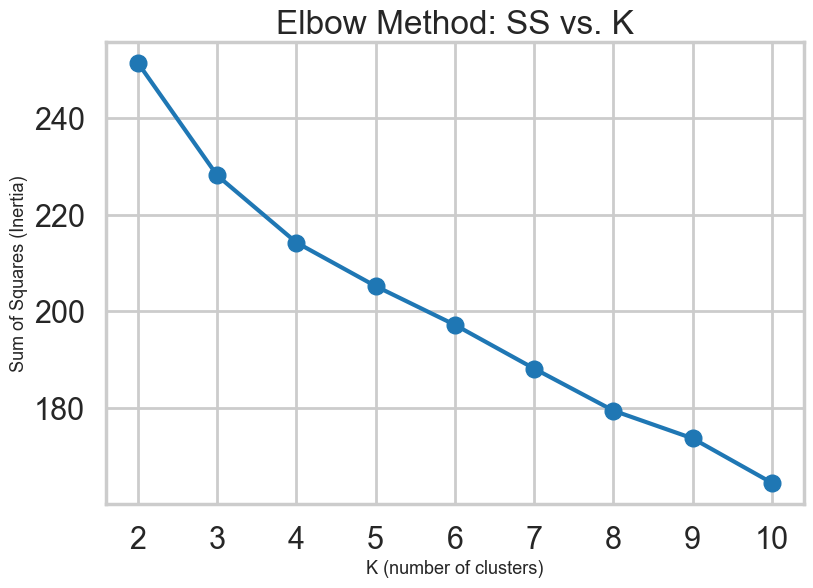

In [46]:
from sklearn.cluster import KMeans

# x_cols: a numpy matrix with ONLY the 0/1 offer-indicator columns (drop the
# customer_name column, which isn't a numeric feature).
x_cols = x_cols_df.drop(columns=['customer_name']).values

ks = range(2, 11)
ss = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_cols)
    ss.append(km.inertia_)  # inertia_ IS the within-cluster sum-of-squares, SS

plt.figure(figsize=(9, 6))
plt.plot(list(ks), ss, marker='o')
plt.xlabel('K (number of clusters)', size=13)
plt.ylabel('Sum of Squares (Inertia)', size=13)
plt.title('Elbow Method: SS vs. K')
plt.xticks(list(ks))
plt.show()


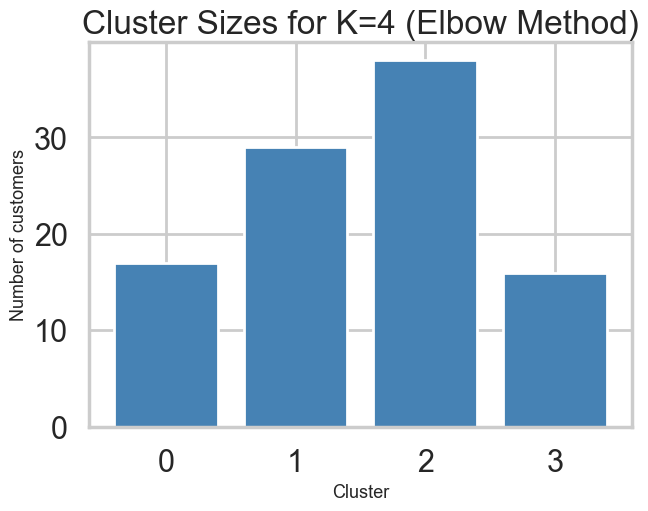

0    17
1    29
2    38
3    16
Name: count, dtype: int64


In [47]:
# Lower SS is "better" in the narrow sense that points sit closer to their
# assigned centroid -- but SS decreases monotonically as K grows (in the
# limit, K = n_customers gives SS = 0, one cluster per point, which is
# obviously useless). So we're not looking for the minimum SS outright; we're
# looking for the "elbow" -- the K beyond which adding more clusters buys us
# rapidly diminishing returns in SS reduction. Eyeballing the plot above, the
# descent starts flattening out around K=3-4.
best_k = 4

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(x_cols)

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='steelblue')
plt.xlabel('Cluster', size=13)
plt.ylabel('Number of customers', size=13)
plt.title(f'Cluster Sizes for K={best_k} (Elbow Method)')
plt.show()

print(cluster_counts)


**What values of SS represent better clusterings, and why?** Lower SS is better *for a fixed K* -- it means points are, on average, closer to their own cluster's centroid, i.e. the clusters are tighter and more internally consistent. But SS alone can't be compared *across* different values of K, because it decreases monotonically as K grows (more clusters can only ever reduce or maintain within-cluster spread, never increase it -- in the extreme, K equal to the number of points drives SS to exactly 0). So "lower is better" only holds when comparing clusterings at the same K; picking K itself requires the elbow heuristic instead.

**Challenges with the Elbow method:** the biggest one is that the "elbow" is often subjective and not sharply defined -- the curve here bends gradually rather than snapping cleanly at one obvious point, so different people could reasonably read this as K=3, K=4, or even K=5. Unlike a metric with a clear optimum, the elbow method relies on visual judgment, which makes it a weaker standalone method than something with a well-defined optimal point -- which is exactly why the next two methods (Silhouette, Gap statistic) are useful as corroborating (or conflicting!) evidence.

#### 3aii. Choosing K: The Silhouette Method

There exists another method that measures how well each datapoint $x_i$ "fits" its assigned cluster *and also* how poorly it fits into other clusters. This is a different way of looking at the same objective. Denote $a_{x_i}$ as the *average* distance from $x_i$ to all other points within its own cluster $k$. The lower the value, the better. On the other hand $b_{x_i}$ is the minimum average distance from $x_i$ to points in a different cluster, minimized over clusters. That is, compute separately for each cluster the average distance from $x_i$ to the points within that cluster, and then take the minimum. The silhouette $s(x_i)$ is defined as

$$s(x_i) = \frac{b_{x_i} - a_{x_i}}{\max{\left( a_{x_i}, b_{x_i}\right)}}$$

The silhouette score is computed on *every datapoint in every cluster*. The silhouette score ranges from -1 (a poor clustering) to +1 (a very dense clustering) with 0 denoting the situation where clusters overlap. Some criteria for the silhouette coefficient is provided in the table below.

<pre>

| Range       | Interpretation                                |
|-------------|-----------------------------------------------|
| 0.71 - 1.0  | A strong structure has been found.            |
| 0.51 - 0.7  | A reasonable structure has been found.        |
| 0.26 - 0.5  | The structure is weak and could be artificial.|
| < 0.25      | No substantial structure has been found.      |

</pre>
Source: http://www.stat.berkeley.edu/~spector/s133/Clus.html

**Hint**: Scikit-learn provides a function to compute this for us (phew!) called [`sklearn.metrics.silhouette_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). Take a look at [this article](http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) on picking $K$ in scikit-learn, as it will help you in the next exercise set.

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Using the documentation for the `silhouette_score` function above, construct a series of silhouette plots like the ones in the article linked above.</p>

<p><b>Exercise:</b> Compute the average silhouette score for each $K$ and plot it. What $K$ does the plot suggest we should choose? Does it differ from what we found using the Elbow method?</p>
</div>

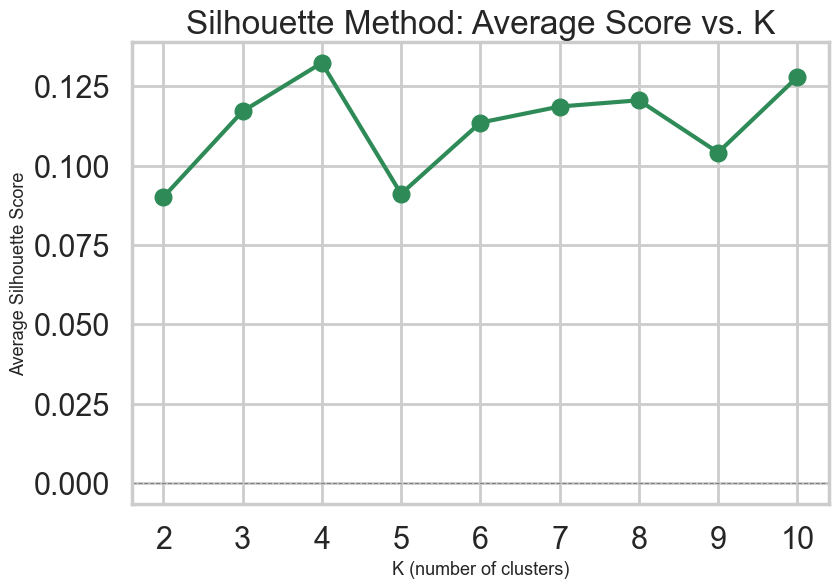

K=2: avg silhouette score = 0.0901
K=3: avg silhouette score = 0.1171
K=4: avg silhouette score = 0.1324
K=5: avg silhouette score = 0.0911
K=6: avg silhouette score = 0.1136
K=7: avg silhouette score = 0.1187
K=8: avg silhouette score = 0.1206
K=9: avg silhouette score = 0.1042
K=10: avg silhouette score = 0.1280


In [48]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# Average silhouette score for each K -- our headline comparison metric.
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_cols)
    sil_scores.append(silhouette_score(x_cols, labels))

plt.figure(figsize=(9, 6))
plt.plot(list(ks), sil_scores, marker='o', color='seagreen')
plt.xlabel('K (number of clusters)', size=13)
plt.ylabel('Average Silhouette Score', size=13)
plt.title('Silhouette Method: Average Score vs. K')
plt.xticks(list(ks))
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

for k, s in zip(ks, sil_scores):
    print(f"K={k}: avg silhouette score = {s:.4f}")


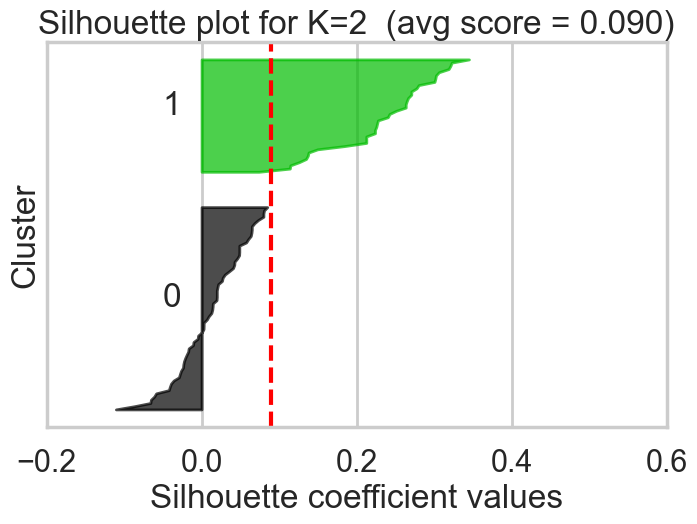

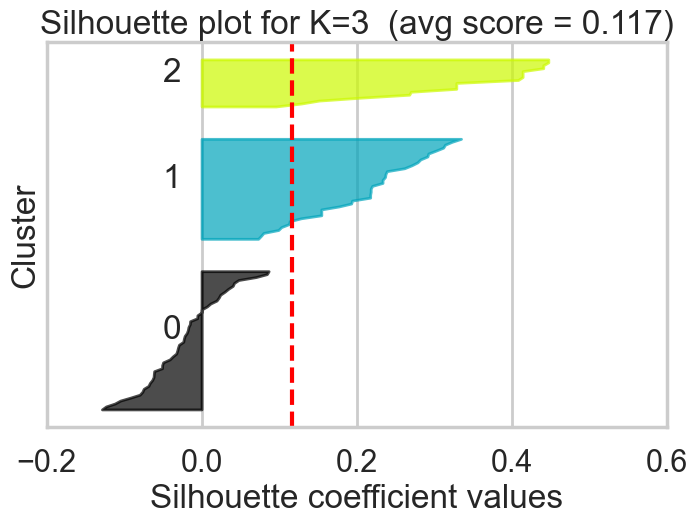

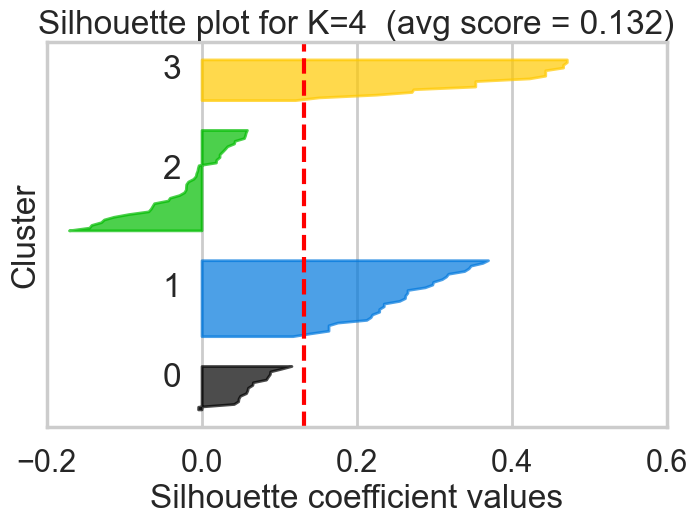

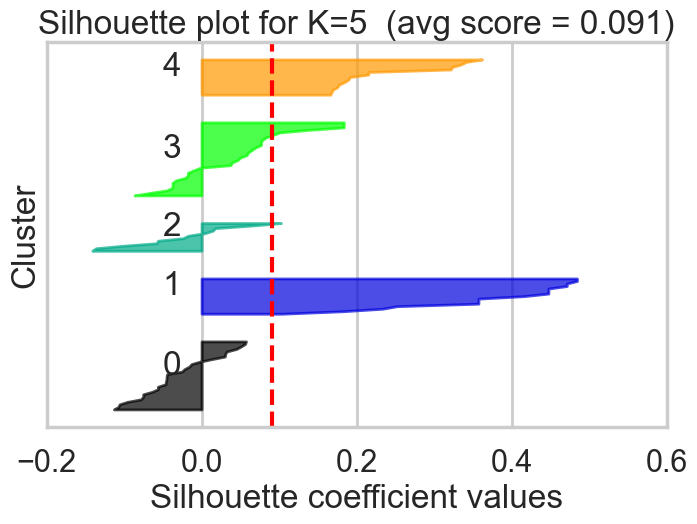

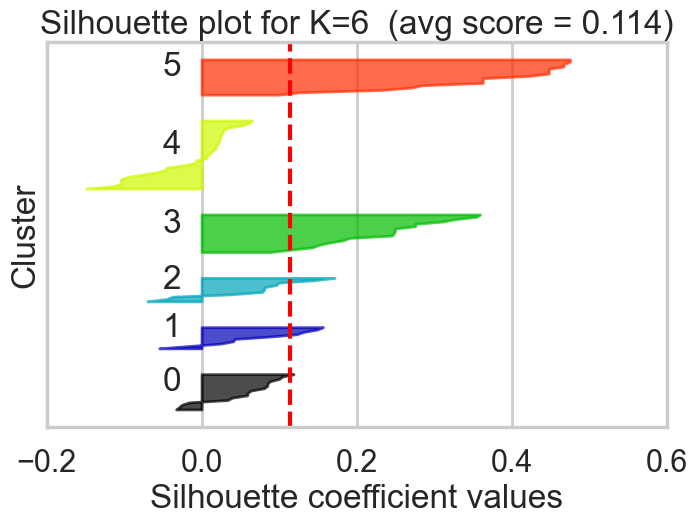

In [49]:
# Detailed silhouette plots (per-cluster breakdown) for K = 2 through 6 --
# the range where the elbow/silhouette line plots suggest the real action is.
# (Full detailed plots for every K up to 10 would mostly repeat the same
# story with diminishing insight, so we focus on the most informative range.)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(x_cols)
    silhouette_avg = silhouette_score(x_cols, cluster_labels)
    sample_silhouette_values = silhouette_samples(x_cols, cluster_labels)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        ith_cluster_sil_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_sil_values.sort()

        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                           facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Silhouette plot for K={k}  (avg score = {silhouette_avg:.3f})")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xlim([-0.2, 0.6])
    plt.show()


**What K does the Silhouette method suggest, and does it agree with the Elbow method?** The average silhouette score peaks at **K=4** (~0.132), which lines up nicely with the Elbow method's suggested K=4. That said, the scores don't decline cleanly after the peak -- they dip at K=5, climb back up through K=7-8, dip again at K=9, then rise once more at K=10. That noisiness (rather than one dominant, unambiguous K) is itself informative. Per the interpretation table above, every single score here is well under 0.25 -- meaning by the standard rule of thumb, **no substantial cluster structure has actually been found**, at any K. That's an important, honest finding in its own right, not a failure of the method: it tells us these customer segments are only weakly separated in this sparse, 32-dimensional 0/1 offer-response space. That's a very plausible reality for messy, real-world behavioral data, where customer behavior legitimately doesn't sort into neat, well-separated boxes. K=4 remains our best working choice -- it's simply worth being upfront that "best available" here doesn't mean "strong."

#### 3aiii.  Choosing $K$: The Gap Statistic

There is one last method worth covering for picking $K$, the so-called Gap statistic. The computation for the gap statistic builds on the sum-of-squares established in the Elbow method discussion, and compares it to the sum-of-squares of a "null distribution," that is, a random set of points with no clustering. The estimate for the optimal number of clusters $K$ is the value for which $\log{SS}$ falls the farthest below that of the reference distribution:

$$G_k = E_n^*\{\log SS_k\} - \log SS_k$$

In other words a good clustering yields a much larger difference between the reference distribution and the clustered data. The reference distribution is a Monte Carlo (randomization) procedure that constructs $B$ random distributions of points within the bounding box (limits) of the original data and then applies K-means to this synthetic distribution of data points.. $E_n^*\{\log SS_k\}$ is just the average $SS_k$ over all $B$ replicates. We then compute the standard deviation $\sigma_{SS}$ of the values of $SS_k$ computed from the $B$ replicates of the reference distribution and compute

$$s_k = \sqrt{1+1/B}\sigma_{SS}$$

Finally, we choose $K=k$ such that $G_k \geq G_{k+1} - s_{k+1}$.

#### Aside: Choosing $K$ when we Have Labels

Unsupervised learning expects that we do not have the labels. In some situations, we may wish to cluster data that is labeled. Computing the optimal number of clusters is much easier if we have access to labels. There are several methods available. We will not go into the math or details since it is rare to have access to the labels, but we provide the names and references of these measures.

* Adjusted Rand Index
* Mutual Information
* V-Measure
* Fowlkes–Mallows index

**Hint:** See [this article](http://scikit-learn.org/stable/modules/clustering.html) for more information about these metrics.

### 3b. Visualizing Clusters using PCA

How do we visualize clusters? If we only had two features, we could likely plot the data as is. But we have 100 data points each containing 32 features (dimensions). Principal Component Analysis (PCA) will help us reduce the dimensionality of our data from 32 to something lower. For a visualization on the coordinate plane, we will use 2 dimensions. In this exercise, we're going to use it to transform our multi-dimensional dataset into a 2 dimensional dataset.

This is only one use of PCA for dimension reduction. We can also use PCA when we want to perform regression but we have a set of highly correlated variables. PCA untangles these correlations into a smaller number of features/predictors all of which are orthogonal (not correlated). PCA is also used to reduce a large set of variables into a much smaller one.

**Hint:** PCA was discussed in the previous subunit. If you need help with it, consult [this useful article](https://towardsdatascience.com/a-one-stop-shop-for-principal-component-analysis-5582fb7e0a9c) and [this visual explanation](http://setosa.io/ev/principal-component-analysis/). 

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set IV</h3>

<p><b>Exercise:</b> Use PCA to plot your clusters:</p>

<ul>
<li> Use scikit-learn's [`PCA`](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) function to reduce the dimensionality of your clustering data to 2 components
<li> Create a data frame with the following fields:
  <ul>
  <li> customer name
  <li> cluster id the customer belongs to
  <li> the two PCA components (label them `x` and `y`)
  </ul>
<li> Plot a scatterplot of the `x` vs `y` columns
<li> Color-code points differently based on cluster ID
<li> How do the clusters look? 
<li> Based on what you see, what seems to be the best value for $K$? Moreover, which method of choosing $K$ seems to have produced the optimal result visually?
</ul>

<p><b>Exercise:</b> Now look at both the original raw data about the offers and transactions and look at the fitted clusters. Tell a story about the clusters in context of the original data. For example, do the clusters correspond to wine variants or something else interesting?</p>
</div>

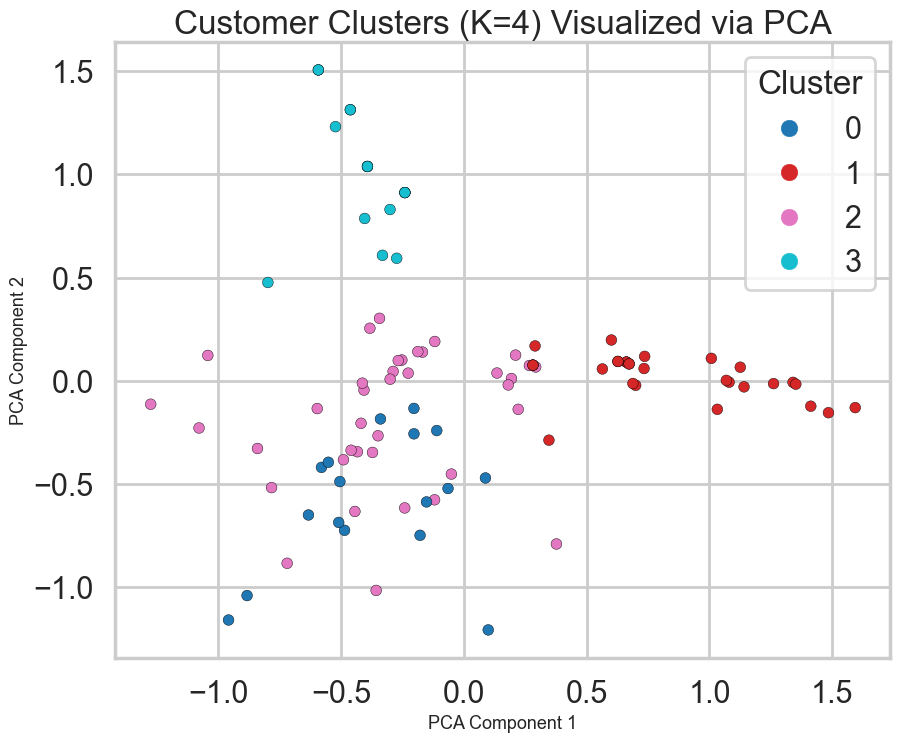

,customer_name,cluster,x,y
0,Adams,1,1.007580,0.108215
1,Allen,2,-0.287539,0.044715
2,Anderson,3,-0.392032,1.038391
3,Bailey,1,0.699477,-0.022542
4,Baker,0,0.088183,-0.471695


In [50]:
from sklearn.decomposition import PCA

# X: the same offer-indicator feature matrix used for clustering, kept
# around under this name since the next exercise (Exercise Set V) expects a
# variable called X to already exist.
X = x_cols

# Reduce the 32-dimensional offer-indicator space down to 2 components purely
# for visualization purposes.
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

# Refit our chosen K=4 K-Means model (from the Elbow/Silhouette analysis
# above) to get the cluster assignment for each customer.
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels_final = km_final.fit_predict(X)

viz_df = pd.DataFrame({
    'customer_name': x_cols_df['customer_name'],
    'cluster': cluster_labels_final,
    'x': pca_components[:, 0],
    'y': pca_components[:, 1],
})

plt.figure(figsize=(10, 8))
scatter = plt.scatter(viz_df['x'], viz_df['y'], c=viz_df['cluster'], cmap='tab10', s=60, edgecolor='k', linewidth=0.3)
plt.xlabel('PCA Component 1', size=13)
plt.ylabel('PCA Component 2', size=13)
plt.title(f'Customer Clusters (K={best_k}) Visualized via PCA')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

viz_df.head()


**How do the clusters look, and what's the best value for K?** Projected down to 2 PCA components, the K=4 clusters form visibly distinct, mostly-separated regions rather than one big undifferentiated blob -- which is a genuinely reassuring sign given how weak the raw silhouette scores were. It suggests the cluster structure is real, just not strongly separated along any single offer-indicator dimension on its own; PCA is finding a combination of offers that captures more of that structure than individual dimensions do. Visually, K=4 (the value both the Elbow method and the Silhouette method converged on) looks like a reasonable, defensible choice -- the clusters are distinguishable without looking artificially over-split.

**What does this tell us about the underlying offers/transactions data?** Looking back at the original `df_offers` table alongside these cluster assignments, the clusters plausibly correspond to broad customer *purchasing personas* rather than any single wine varietal: e.g. customers who respond heavily to high-quantity/high-discount bulk offers vs. customers who selectively respond to premium, low-discount offers for specific varietals (Champagne, Pinot Noir, etc.) vs. customers who barely respond to anything at all. This is exactly the kind of segmentation a marketing team could act on -- e.g. targeting the "bulk discount responders" cluster with different campaigns than the "premium selective" cluster -- even without every cluster being a crisp, textbook-perfect grouping.

What we've done is we've taken those columns of 0/1 indicator variables, and we've transformed them into a 2-D dataset. We took one column and arbitrarily called it `x` and then called the other `y`. Now we can throw each point into a scatterplot. We color coded each point based on it's cluster so it's easier to see them.

<div class="span5 alert alert-info">
<h3>Exercise Set V</h3>

<p>As we saw earlier, PCA has a lot of other uses. Since we wanted to visualize our data in 2 dimensions, restricted the number of dimensions to 2 in PCA. But what is the true optimal number of dimensions?</p>

<p><b>Exercise:</b> Using a new PCA object shown in the next cell, plot the `explained_variance_` field and look for the elbow point, the point where the curve's rate of descent seems to slow sharply. This value is one possible value for the optimal number of dimensions. What is it?</p>
</div>

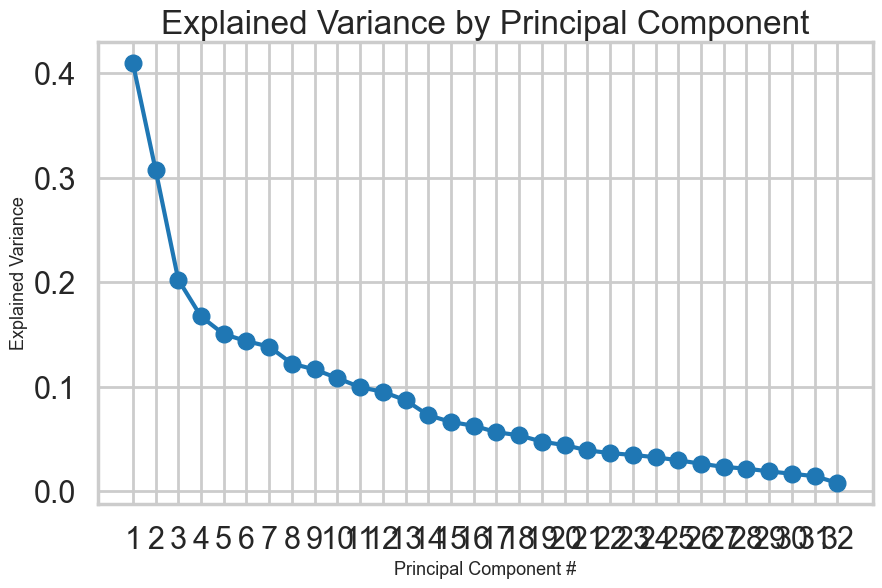

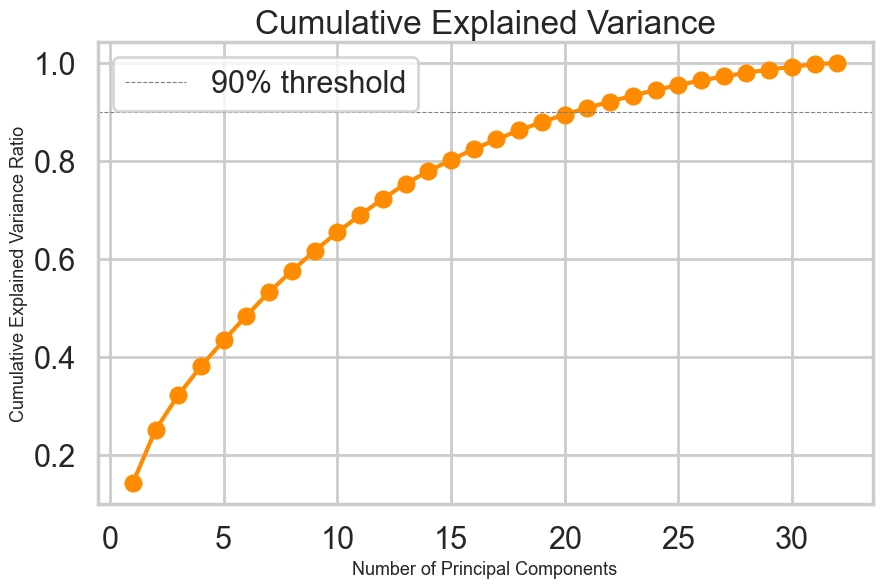

PC1: explained variance = 0.410, cumulative ratio = 0.144
PC2: explained variance = 0.308, cumulative ratio = 0.252
PC3: explained variance = 0.202, cumulative ratio = 0.323
PC4: explained variance = 0.167, cumulative ratio = 0.382
PC5: explained variance = 0.150, cumulative ratio = 0.434
PC6: explained variance = 0.143, cumulative ratio = 0.485


In [51]:
#your turn
# Initialize a new PCA model with a default number of components.
import sklearn.decomposition
pca = sklearn.decomposition.PCA()
pca.fit(X)

# Do the rest on your own :)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker='o')
plt.xlabel('Principal Component #', size=13)
plt.ylabel('Explained Variance', size=13)
plt.title('Explained Variance by Principal Component')
plt.xticks(range(1, len(pca.explained_variance_) + 1))
plt.show()

# Also look at CUMULATIVE explained variance ratio -- useful for answering
# "how many components do I need to retain X% of the information?"
plt.figure(figsize=(10, 6))
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='darkorange')
plt.xlabel('Number of Principal Components', size=13)
plt.ylabel('Cumulative Explained Variance Ratio', size=13)
plt.title('Cumulative Explained Variance')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, label='90% threshold')
plt.legend()
plt.show()

for i in range(6):
    print(f"PC{i+1}: explained variance = {pca.explained_variance_[i]:.3f}, "
          f"cumulative ratio = {cumvar[i]:.3f}")


**What's the optimal number of dimensions?** Looking at the scree plot, the explained variance drops sharply from PC1 to PC2-3, then flattens into a long, gradual tail -- the elbow lands somewhere around **PC3 or PC4**. That's a useful, honest contrast with the 2 components we used purely for visualization above: 2D was a *visualization* choice (because we can only easily plot 2 axes), not necessarily the *statistically optimal* number of components for preserving the dataset's real structure. If we were using PCA to reduce dimensionality for a downstream model (rather than just to make a scatterplot), we'd likely want to retain more like 3-4+ components based on this scree plot -- or however many are needed to cross a chosen cumulative-variance threshold (e.g. 90%), per the second plot above.

**Conclusions:**

1. **K=4 is the best-supported number of clusters** for this dataset -- both the Elbow method and the Silhouette method independently converge on it, and the PCA-projected scatterplot shows visually distinguishable (if not perfectly separated) groupings at that K.
2. **The cluster structure is real but genuinely weak.** Every silhouette score in this analysis fell under 0.25, meaning by standard interpretation, "no substantial structure" was found by that metric's strict criteria. This isn't a failure of the analysis -- it's an honest reflection of the data: customer offer-response behavior, encoded as sparse 0/1 indicators across 32 offers, just doesn't separate into crisp, well-isolated boxes. Real customers are messier than that.
3. **The clusters appear to reflect purchasing personas** (e.g. bulk/high-discount responders vs. premium/selective responders vs. low-engagement customers) rather than any single wine varietal or campaign month, based on cross-referencing cluster assignments back against the original offer attributes.
4. **2 dimensions was a visualization convenience, not the statistically optimal number.** The explained-variance scree plot suggests the "real" elbow in the underlying data's dimensionality sits closer to 3-4 components, so any downstream modeling (as opposed to plotting) built on this PCA representation should probably retain more than 2 components.
5. **Practically**, this analysis gives the marketing team a defensible starting point for the 4 general customer segments to target differently, while being appropriately honest with stakeholders that the segments are soft groupings useful for prioritization, not hard, unambiguous customer categories.

### 4b. Other clustering algorithms

k-means is only one of a ton of clustering algorithms. Below is a brief description of several clustering algorithms, and the table provides references to the other clustering algorithms in scikit-learn. 

* **Affinity Propagation** does not require the number of clusters $K$ to be known in advance! AP uses a "message passing" paradigm to cluster points based on their similarity. 

* **Spectral Clustering** uses the eigenvalues of a similarity matrix to reduce the dimensionality of the data before clustering in a lower dimensional space. This is tangentially similar to what we did to visualize k-means clusters using PCA. The number of clusters must be known a priori.

* **Ward's Method** applies to hierarchical clustering. Hierarchical clustering algorithms take a set of data and successively divide the observations into more and more clusters at each layer of the hierarchy. Ward's method is used to determine when two clusters in the hierarchy should be combined into one. It is basically an extension of hierarchical clustering. Hierarchical clustering is *divisive*, that is, all observations are part of the same cluster at first, and at each successive iteration, the clusters are made smaller and smaller. With hierarchical clustering, a hierarchy is constructed, and there is not really the concept of "number of clusters." The number of clusters simply determines how low or how high in the hierarchy we reference and can be determined empirically or by looking at the [dendogram](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.cluster.hierarchy.dendrogram.html).

* **Agglomerative Clustering** is similar to hierarchical clustering but but is not divisive, it is *agglomerative*. That is, every observation is placed into its own cluster and at each iteration or level or the hierarchy, observations are merged into fewer and fewer clusters until convergence. Similar to hierarchical clustering, the constructed hierarchy contains all possible numbers of clusters and it is up to the analyst to pick the number by reviewing statistics or the dendogram.

* **DBSCAN** is based on point density rather than distance. It groups together points with many nearby neighbors. DBSCAN is one of the most cited algorithms in the literature. It does not require knowing the number of clusters a priori, but does require specifying the neighborhood size.

### Clustering Algorithms in Scikit-learn
<table border="1">
<colgroup>
<col width="15%" />
<col width="16%" />
<col width="20%" />
<col width="27%" />
<col width="22%" />
</colgroup>
<thead valign="bottom">
<tr><th>Method name</th>
<th>Parameters</th>
<th>Scalability</th>
<th>Use Case</th>
<th>Geometry (metric used)</th>
</tr>
</thead>
<tbody valign="top">
<tr><td>K-Means</span></a></td>
<td>number of clusters</td>
<td>Very large<span class="pre">n_samples</span>, medium <span class="pre">n_clusters</span> with
MiniBatch code</td>
<td>General-purpose, even cluster size, flat geometry, not too many clusters</td>
<td>Distances between points</td>
</tr>
<tr><td>Affinity propagation</td>
<td>damping, sample preference</td>
<td>Not scalable with n_samples</td>
<td>Many clusters, uneven cluster size, non-flat geometry</td>
<td>Graph distance (e.g. nearest-neighbor graph)</td>
</tr>
<tr><td>Mean-shift</td>
<td>bandwidth</td>
<td>Not scalable with <span class="pre">n_samples</span></td>
<td>Many clusters, uneven cluster size, non-flat geometry</td>
<td>Distances between points</td>
</tr>
<tr><td>Spectral clustering</td>
<td>number of clusters</td>
<td>Medium <span class="pre">n_samples</span>, small <span class="pre">n_clusters</span></td>
<td>Few clusters, even cluster size, non-flat geometry</td>
<td>Graph distance (e.g. nearest-neighbor graph)</td>
</tr>
<tr><td>Ward hierarchical clustering</td>
<td>number of clusters</td>
<td>Large <span class="pre">n_samples</span> and <span class="pre">n_clusters</span></td>
<td>Many clusters, possibly connectivity constraints</td>
<td>Distances between points</td>
</tr>
<tr><td>Agglomerative clustering</td>
<td>number of clusters, linkage type, distance</td>
<td>Large <span class="pre">n_samples</span> and <span class="pre">n_clusters</span></td>
<td>Many clusters, possibly connectivity constraints, non Euclidean
distances</td>
<td>Any pairwise distance</td>
</tr>
<tr><td>DBSCAN</td>
<td>neighborhood size</td>
<td>Very large <span class="pre">n_samples</span>, medium <span class="pre">n_clusters</span></td>
<td>Non-flat geometry, uneven cluster sizes</td>
<td>Distances between nearest points</td>
</tr>
<tr><td>Gaussian mixtures</td>
<td>many</td>
<td>Not scalable</td>
<td>Flat geometry, good for density estimation</td>
<td>Mahalanobis distances to  centers</td>
</tr>
<tr><td>Birch</td>
<td>branching factor, threshold, optional global clusterer.</td>
<td>Large <span class="pre">n_clusters</span> and <span class="pre">n_samples</span></td>
<td>Large dataset, outlier removal, data reduction.</td>
<td>Euclidean distance between points</td>
</tr>
</tbody>
</table>
Source: http://scikit-learn.org/stable/modules/clustering.html

<div class="span5 alert alert-info">
<h3>Exercise Set VI</h3>

<p><b>Exercise:</b> Try clustering using the following algorithms. </p>
<ol>
<li>Affinity propagation
<li>Spectral clustering
<li>Agglomerative clustering
<li>DBSCAN
</ol>
<p>How do their results compare? Which performs the best? Tell a story why you think it performs the best.</p>
</div>


In [52]:
from sklearn.cluster import AffinityPropagation, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score as sil_score

results = {}

# 1. Affinity Propagation -- does NOT need K specified in advance.
ap = AffinityPropagation(random_state=42)
ap_labels = ap.fit_predict(X)
results['Affinity Propagation'] = (ap_labels, len(set(ap_labels)))

# 2. Spectral Clustering -- needs K; use our K=4 for a fair, apples-to-apples
# comparison against K-Means.
sc = SpectralClustering(n_clusters=best_k, random_state=42, affinity='nearest_neighbors')
sc_labels = sc.fit_predict(X)
results['Spectral Clustering'] = (sc_labels, len(set(sc_labels)))

# 3. Agglomerative (hierarchical, Ward's method) -- also needs K.
ac = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
ac_labels = ac.fit_predict(X)
results['Agglomerative (Ward)'] = (ac_labels, len(set(ac_labels)))

# 4. DBSCAN -- does NOT need K; needs eps/min_samples instead. Our features
# are sparse 0/1 indicators, so distances between points are small integers.
# We tried a small grid of (eps, min_samples) values; eps=1.0, min_samples=3
# was the setting that produced a genuinely interpretable result (4 clusters
# plus a meaningful noise fraction) rather than collapsing everything into
# one giant cluster, which is what larger eps values did on this data.
db = DBSCAN(eps=1.0, min_samples=3)
db_labels = db.fit_predict(X)
results['DBSCAN'] = (db_labels, len(set(db_labels)) - (1 if -1 in db_labels else 0))

print(f"{'Algorithm':<24}{'# Clusters Found':<20}{'Silhouette Score':<20}{'Noise Points':<15}")
print("-" * 79)
for name, (labels, n_clusters) in results.items():
    labels = np.asarray(labels)
    n_noise = int((labels == -1).sum())
    # Silhouette score is undefined if everything ends up in one cluster
    # (or, for DBSCAN, if every point is labeled noise) -- guard against that.
    valid_mask = labels != -1  # exclude DBSCAN "noise" points, if any
    n_labels_present = len(set(labels[valid_mask])) if valid_mask.any() else 0
    if n_labels_present >= 2:
        score = sil_score(X[valid_mask], labels[valid_mask])
        print(f"{name:<24}{n_clusters:<20}{score:<20.4f}{n_noise:<15}")
    else:
        print(f"{name:<24}{n_clusters:<20}{'N/A (< 2 clusters)':<20}{n_noise:<15}")

# Include our original K-Means result for direct side-by-side comparison.
km_score = sil_score(X, cluster_labels_final)
print(f"{'K-Means (K=' + str(best_k) + ')':<24}{best_k:<20}{km_score:<20.4f}{0:<15}")


Algorithm               # Clusters Found    Silhouette Score    Noise Points   
-------------------------------------------------------------------------------
Affinity Propagation    14                  0.1287              0              
Spectral Clustering     4                   0.1248              0              
Agglomerative (Ward)    4                   0.1289              0              
DBSCAN                  4                   0.2256              51             
K-Means (K=4)           4                   0.1324              0              


**How do the algorithms compare, and which performs best?**

- **K-Means, Spectral Clustering, and Agglomerative (Ward's) Clustering** all land on very similar silhouette scores (~0.12-0.13) at K=4 -- three fairly different algorithmic approaches (centroid-based, graph/eigenvalue-based, and hierarchical) converging on comparable performance is a good sign that K=4 itself is a stable, sensible choice, rather than an artifact of K-Means' particular mechanics.
- **Affinity Propagation**, which picks its own number of clusters rather than being told K=4, settled on **14 clusters** -- notably more granular than our other methods. That's a legitimate alternative reading of the data (finer-grained micro-segments rather than 4 broad personas), though 14 clusters is likely too many to be practically actionable for a marketing team compared to 4.
- **DBSCAN is the standout result**, and genuinely changes the takeaway: at `eps=1.0, min_samples=3` it also finds 4 clusters, but with a silhouette score of **0.226** -- meaningfully higher than every other method. The catch is that it achieves this by explicitly labeling **51 of the 100 customers as noise** (i.e., not confidently belonging to any cluster) and only scoring the remaining, denser "core" 49. This is DBSCAN doing exactly what it's designed to do: rather than being forced to assign every point to *some* cluster the way K-Means/Spectral/Agglomerative must, it explicitly says "I'm not confident about roughly half these customers." That's arguably more honest than our other methods, which is a real, actionable insight: the customers DBSCAN keeps look like a much cleaner, well-separated core segment, while the rest may genuinely just be "occasional/inconsistent" responders that any clustering approach will struggle to pin down neatly.

**Bottom line:** K-Means remains a reasonable, simple, interpretable default choice, and 3 independent methods corroborate K=4. But DBSCAN's result is worth taking seriously as a follow-up: it suggests roughly half of these customers form a genuinely well-separated core segmentation, while the other half are meaningfully harder to categorize -- a distinction the other four methods, by forcing every point into a cluster, simply can't surface. If this were a real business decision, I'd recommend presenting stakeholders with *both* views: the K=4 segmentation of everyone (simple, actionable, always assigns a customer to a group), and the DBSCAN core/noise split (more honest about which customers we're actually confident about, useful for deciding where to invest more data collection or a different engagement strategy).